In [1]:
import json
import os
import difflib
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoTokenizer
from IPython.display import display, HTML
import ftfy

from utils.generic import read_json

## Text Highlights

In [3]:
root_output_path = "../data/output/"
gumbel_data = read_json(os.path.join(root_output_path, "data_facebook-opt-125m_n100_gumbel.json"))
gumbel_data['configuration']

{'model_name': 'facebook/opt-125m',
 'intervals': [[0, 20, 'unwatermarked'],
  [20, 50, 'gumbel'],
  [50, 100, 'unwatermarked']],
 'prompt_tokens': 50,
 'out_tokens': 100,
 'vocab_size': 50272,
 'initial_seed': 1234,
 'max_token_input_length': 256}

In [4]:
def view_text_highlight(sample_index: int, data):
    model_name = data['configuration']['model_name']
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    raw_text = ftfy.fix_text(data['data'][sample_index]['output'])
    encoding = tokenizer(raw_text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

    def clean_tokens(tokens):
        cleaned = []
        for token in tokens:
            # Convert token to ID
            try:
                token_id = tokenizer.convert_tokens_to_ids(token)
                text = tokenizer.decode([token_id], clean_up_tokenization_spaces=True)
            except KeyError:
                text = ""  # fallback if token not in vocab

            # Optional: map common special tokens
            if text == "</s>" or text == "<s>":
                text = ""

            cleaned.append(text)
        return cleaned 

    cleaned_tokens = clean_tokens(tokens)

    prompt_tokens = data['configuration']['prompt_tokens']
    intervals = data['configuration']['intervals']
    desc = [
        ((0, prompt_tokens), "#d0e1ff", "Input")
    ]
    for start, end, type in intervals:
        if type == "unwatermarked":
            desc.append(((start + prompt_tokens, end + prompt_tokens), "#e0e0e0", "Unwatermarked"))
        else:
            desc.append(((start + prompt_tokens, end + prompt_tokens), "#ffd6d6", f"{type.capitalize()} Watermark"))

    html_tokens = []
    label_mapper = {}

    for idx, tok in enumerate(cleaned_tokens):
        label = None
        for key, (interval, color, label) in enumerate(desc):
            start, end = interval
            if start <= idx < end:
                label = str(key)
                html_tokens.append(
                    f"<span style='background:{color}; color:black;"
                    f"border-radius:3px; margin:1px;'>{tok}</span>"
                )
                break
            if label not in label_mapper:
                label_mapper[str(label)] = color
            
    legend_html = "".join(
        f"<span style='background:{c}; color:black; padding:2px 5px; border-radius:3px; margin-right:8px;'>{lbl}</span>"
        for lbl, c in label_mapper.items()
    )


    display(HTML(f"""
    <div style="background:white; padding:10px; font-family:monospace; line-height:1.6; font-size:14px;">
        <div style="margin-bottom:8px;">Legend: {legend_html}</div>
    {''.join(html_tokens)}
    </div>
    """))

sample_index = 15
view_text_highlight(sample_index, gumbel_data)

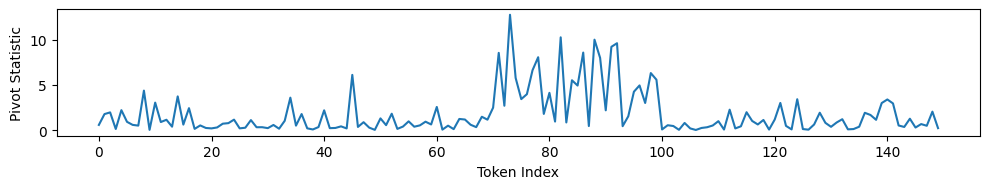

In [7]:
import numpy as np

# generate diagram
sample_index = 40
fname = "data_facebook-opt-125m_n100_gumbel.json"
dat = read_json(os.path.join("../data/output", fname))
pivots = np.concatenate([
    np.random.exponential(scale = 1, size = 50),
    dat['data'][sample_index]['pivots']
])

df = pd.DataFrame({'token_index': range(len(pivots)), 'pivot_statistic': pivots })
plt.figure(figsize=(10, 2))
sns.lineplot(data=df, x='token_index', y='pivot_statistic')
plt.xlabel('Token Index')
plt.ylabel('Pivot Statistic')
plt.tight_layout()

plt.savefig("../figures/wm_diagram_pivot.pdf", dpi = 300)
plt.show()

## Simulation 1

In [14]:
# read simulation 1 data
df = pd.read_csv("../data/simulations/simulation1_all_WISER.csv")
mapping_dict = {"gumbel": "Gumbel", "inverse": "Inverse", "redgreen": "Red-Green", "pf": "Permute-and-Flip"}
df['watermark_type'] = df['watermark_type'].map(mapping_dict)
df.head()


,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,ar_coeff
0,simulation 1,0.968968,0.97600,0.915952,0.996016,0.986250,1.0000,0.993077,0.971460,0.979808,...,0.000047,0.000198,0.0275,0.0000,0.9725,1000,500,Gumbel,1234,0.1
1,simulation 1,0.898420,0.91573,0.733318,0.988048,0.832458,1.0000,0.908570,0.911402,0.924878,...,0.000047,0.000209,0.3215,0.0000,0.6785,1000,500,Inverse,1234,0.1
2,simulation 1,0.245201,0.28800,0.000000,0.720000,0.522083,0.5885,0.553306,0.590483,0.622758,...,0.000025,0.000213,0.1305,0.4115,0.4580,1000,500,Red-Green,1234,0.1
3,simulation 1,0.941182,0.96000,0.808000,0.988000,0.787000,1.0000,0.880806,0.922681,0.957900,...,0.000048,0.000226,0.4195,0.0000,0.5805,1000,500,Permute-and-Flip,1234,0.1
4,simulation 1,0.980534,0.98800,0.932000,0.996016,0.999500,1.0000,0.999750,0.983396,0.990437,...,0.000047,0.000187,0.0010,0.0000,0.9990,1000,500,Gumbel,1234,0.2


<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_13493/3120577165.py:36: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel(f"$\phi$", fontsize=18, labelpad=10)


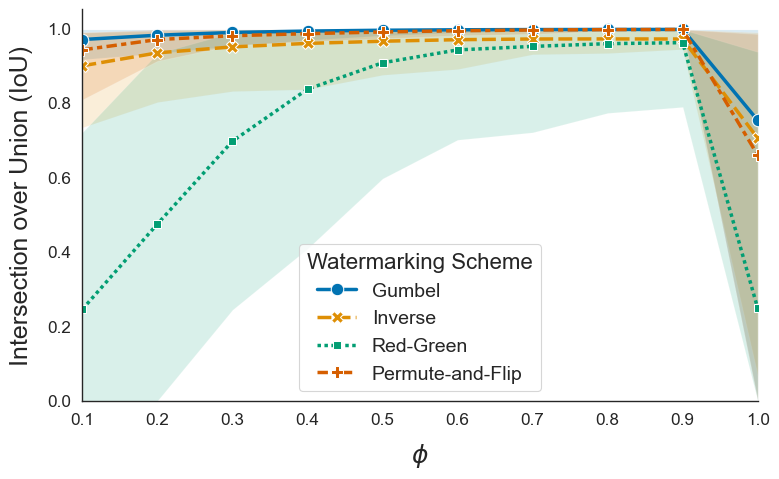

In [15]:
plt.figure(figsize=(8,5))
sns.set_theme(style="white", context="paper", font_scale=1.4)

# color friendly pallete
unique_methods = df['watermark_type'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))

# create confidence bands
for method in unique_methods:
    subset = df[df['watermark_type'] == method].sort_values('ar_coeff')
    plt.fill_between(
        subset['ar_coeff'],
        subset['iou_lower'],
        subset['iou_upper'],
        color=method_colors[method],
        alpha=0.15, # Transparency for the bands
        edgecolor=None # No border on the band
    )

# main lineplot
sns.lineplot(
    data=df,
    x='ar_coeff',
    y='iou',
    hue='watermark_type',
    style='watermark_type',
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling
plt.xlabel(f"$\phi$", fontsize=18, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=18, labelpad=10)

# Axis customization
plt.ylim(0, 1.05)
plt.xlim(df['ar_coeff'].min(), df['ar_coeff'].max())

# Customize the legend
# moving it outside or to a "best" location
plt.legend(title = "Watermarking Scheme", title_fontsize = 16, fontsize = 14, loc = "best")
# plt.legend(title='Watermarking Scheme', title_fontsize=16, fontsize=14, loc='right', frameon=True, framealpha=0.9, bbox_to_anchor=(1.35, 0.5))

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()

plt.savefig("../figures/simulation1_phi.pdf", dpi = 300)  # save the figure

plt.show()

## Simulation 2 (Delta + n)

In [12]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation2_all_WISER.csv")
df['delta'] = df['delta'].astype(str)
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,vocab_size,output_tokens,watermark_type,seed,delta
0,simulation 2,0.002036,0.000000,0.000000,0.000000,0.003000,0.0030,0.003000,0.329420,0.327877,...,0.000011,0.000079,0.0000,0.9970,0.0030,1000,64,partial,1234,1.5
1,simulation 2,0.012216,0.000000,0.000000,0.000000,0.019000,0.0190,0.019000,0.337242,0.327877,...,0.000011,0.000074,0.0000,0.9810,0.0190,1000,64,partial,1234,2.0
2,simulation 2,0.050372,0.000000,0.000000,0.827730,0.065500,0.0655,0.065500,0.364093,0.327877,...,0.000012,0.000100,0.0000,0.9345,0.0655,1000,64,partial,1234,2.5
3,simulation 2,0.163104,0.000000,0.000000,0.960000,0.202000,0.2020,0.202000,0.442990,0.327877,...,0.000012,0.000094,0.0000,0.7980,0.2020,1000,64,partial,1234,3.0
4,simulation 2,0.331886,0.000000,0.000000,0.961538,0.398000,0.3980,0.398000,0.559462,0.327877,...,0.000013,0.000129,0.0000,0.6020,0.3980,1000,64,partial,1234,3.5
5,simulation 2,0.003871,0.000000,0.000000,0.000000,0.007500,0.0075,0.007500,0.338125,0.334523,...,0.000012,0.000075,0.0000,0.9920,0.0080,1000,128,partial,1234,1.5
6,simulation 2,0.033433,0.000000,0.000000,0.627451,0.055750,0.0560,0.055875,0.361841,0.334523,...,0.000013,0.000079,0.0005,0.9435,0.0560,1000,128,partial,1234,2.0
7,simulation 2,0.126165,0.000000,0.000000,0.843137,0.196250,0.1970,0.196624,0.433088,0.334523,...,0.000014,0.000097,0.0015,0.8025,0.1960,1000,128,partial,1234,2.5
8,simulation 2,0.332584,0.000000,0.000000,0.941176,0.463750,0.4670,0.465369,0.580998,0.334523,...,0.000016,0.000123,0.0065,0.5330,0.4605,1000,128,partial,1234,3.0
9,simulation 2,0.606815,0.720305,0.000000,0.980392,0.765750,0.7780,0.771826,0.765780,0.855684,...,0.000019,0.000133,0.0245,0.2220,0.7535,1000,128,partial,1234,3.5


<>:44: SyntaxWarning: invalid escape sequence '\d'
<>:44: SyntaxWarning: invalid escape sequence '\d'
/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_13493/278894697.py:44: SyntaxWarning: invalid escape sequence '\d'
  plt.legend(title=f"$\delta$", title_fontsize=16, fontsize=14, loc='best', frameon=True)


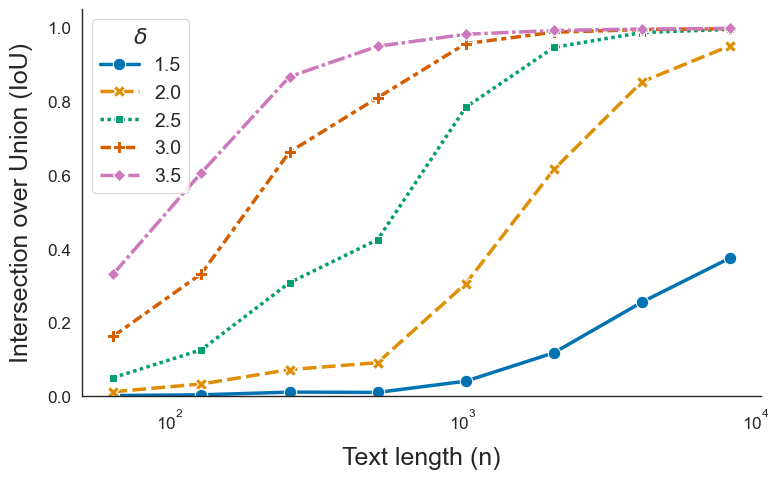

In [13]:
plt.figure(figsize=(8,5))
sns.set_theme(style="white", context="paper", font_scale=1.4)

# color friendly pallete
unique_deltas = df['delta'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_deltas))
delta_colors = dict(zip(unique_deltas, palette))

# # create confidence bands
# for delta in delta_colors:
#     subset = df[df['delta'] == delta].sort_values('output_tokens')
#     plt.fill_between(
#         subset['output_tokens'],
#         subset['iou_lower'],
#         subset['iou_upper'],
#         color=delta_colors[delta],
#         alpha=0.15, # Transparency for the bands
#         edgecolor=None # No border on the band
#     )

# main lineplot
sns.lineplot(
    data=df,
    x='output_tokens',
    y='iou',
    hue='delta',
    style='delta',
    palette=delta_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling and axis
plt.xlabel(f"Text length (n)", fontsize=18, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=18, labelpad=10)
plt.ylim(0, 1.05)
plt.xscale('log')

# Customize the legend
# moving it outside or to a "best" location
# plt.legend(title=f"$\delta$", title_fontsize=16, fontsize=14, loc='right', frameon=True, framealpha=0.9, bbox_to_anchor=(1.2, 0.5))
plt.legend(title=f"$\delta$", title_fontsize=16, fontsize=14, loc='best', frameon=True)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()

plt.savefig("../figures/simulation2A_delta.pdf", dpi = 300)

plt.show()

## Simulation 2B

In [9]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation2B_all_WISER.csv")
df = df.loc[df['d'] <= 3]
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time_lower,time_upper,khat_over,khat_under,khat_exact,kdiff,vocab_size,output_tokens,seed,d
0,simulation 2B,0.002837,0.000000,0.000000,0.000000,0.004000,0.0040,0.004000,0.330060,0.327877,...,0.000011,0.000060,0.0000,0.9955,0.0045,0.997747,1000,64,1234,0.5
1,simulation 2B,0.163046,0.000000,0.000000,0.960000,0.192500,0.1925,0.192500,0.441207,0.327877,...,0.000012,0.000107,0.0000,0.8070,0.1930,0.898332,1000,64,1234,1.0
2,simulation 2B,0.738418,0.892857,0.000000,1.000000,0.825250,0.8255,0.825375,0.833571,0.937500,...,0.000017,0.000120,0.0005,0.1745,0.8250,0.418330,1000,64,1234,1.5
3,simulation 2B,0.910077,0.925926,0.714286,1.000000,0.996250,0.9965,0.996375,0.947765,0.957341,...,0.000029,0.000130,0.0005,0.0035,0.9960,0.063246,1000,64,1234,2.0
4,simulation 2B,0.925277,0.960000,0.735294,1.000000,0.999750,1.0000,0.999875,0.957061,0.978175,...,0.000029,0.000133,0.0005,0.0000,0.9995,0.022361,1000,64,1234,2.5
5,simulation 2B,0.932954,0.960000,0.757576,1.000000,1.000000,1.0000,1.000000,0.961654,0.978175,...,0.000030,0.000137,0.0000,0.0000,1.0000,0.000000,1000,64,1234,3.0
10,simulation 2B,0.004548,0.000000,0.000000,0.000000,0.007500,0.0075,0.007500,0.338195,0.334523,...,0.000011,0.000073,0.0000,0.9925,0.0075,0.996243,1000,128,1234,0.5
11,simulation 2B,0.426391,0.607843,0.000000,0.961538,0.555500,0.5590,0.557245,0.642238,0.815945,...,0.000015,0.000140,0.0070,0.4410,0.5520,0.669328,1000,128,1234,1.0
12,simulation 2B,0.916076,0.944444,0.666667,1.000000,0.990250,0.9950,0.992619,0.953202,0.967889,...,0.000030,0.000140,0.0095,0.0050,0.9855,0.120416,1000,128,1234,1.5
13,simulation 2B,0.955987,0.980392,0.847253,1.000000,1.000000,1.0000,1.000000,0.974708,0.989050,...,0.000031,0.000153,0.0000,0.0000,1.0000,0.000000,1000,128,1234,2.0


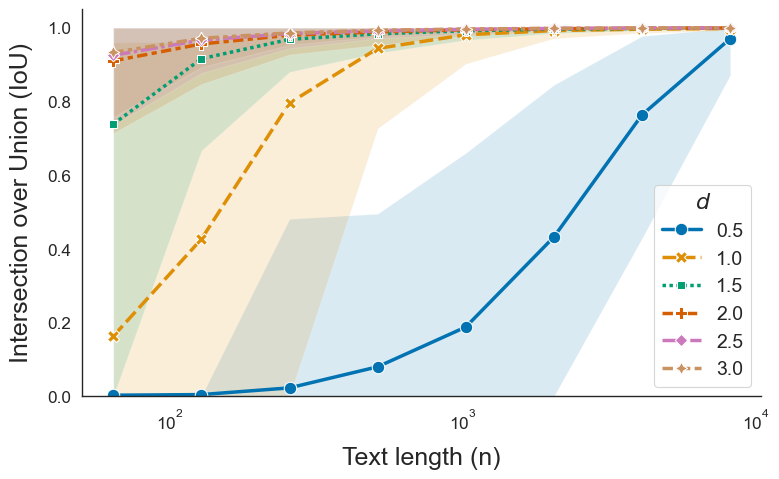

In [11]:
plt.figure(figsize=(8,5))
sns.set_theme(style="white", context="paper", font_scale=1.4)

x_col = "output_tokens"
group_col = "d"
df[group_col] = df[group_col].astype(str)

# color friendly pallete
unique_deltas = df[group_col].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_deltas))
delta_colors = dict(zip(unique_deltas, palette))

# create confidence bands
for delta in delta_colors:
    subset = df[df[group_col] == delta].sort_values(x_col)
    plt.fill_between(
        subset[x_col],
        subset['iou_lower'],
        subset['iou_upper'],
        color=delta_colors[delta],
        alpha=0.15, # Transparency for the bands
        edgecolor=None # No border on the band
    )

# main lineplot
sns.lineplot(
    data=df,
    x=x_col,
    y='iou',
    hue=group_col,
    style=group_col,
    palette=delta_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# Labeling and axis
plt.xlabel(f"Text length (n)", fontsize=18, labelpad=10)
plt.ylabel("Intersection over Union (IoU)", fontsize=18, labelpad=10)
plt.ylim(0, 1.05)
plt.xscale('log')

# Customize the legend
# moving it outside or to a "best" location
# plt.legend(title=f"$d$", title_fontsize=16, fontsize=14, loc='right', frameon=True, framealpha=0.9, bbox_to_anchor = (1.05, 0.5))
plt.legend(title=f"$d$", title_fontsize=16, fontsize=14, loc='best', frameon=True)

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()

plt.savefig("../figures/simulation2B_d.pdf", dpi = 300)
plt.show()

## Simulation 3 (Gap)

In [16]:
# read simulation 3 data
df = pd.read_csv("../data/simulations/simulation3_all_WISER.csv")

print(df.columns)
df.head()

Index(['model_name', 'iou', 'iou_median', 'iou_lower', 'iou_upper',
       'precision', 'recall', 'f1', 'rand_index', 'rand_index_median',
       'rand_index_lower', 'rand_index_upper', 'modified_rand_index',
       'modified_rand_index_median', 'modified_rand_index_lower',
       'modified_rand_index_upper', 'time', 'time_lower', 'time_upper',
       'khat_over', 'khat_under', 'khat_exact', 'kdiff', 'vocab_size',
       'output_tokens', 'watermark_type', 'seed', 'gap', 'gap_prop'],
      dtype='object')


,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,khat_over,khat_under,khat_exact,kdiff,vocab_size,output_tokens,watermark_type,seed,gap,gap_prop
0,simulation 3,0.886894,0.932099,0.593387,0.968153,1.000000,0.411000,0.582566,0.931610,0.931132,...,0.0,0.9960,0.0040,1.819066,1000,512,gumbel,1234,2,0.10
1,simulation 3,0.855668,0.909909,0.576923,0.949686,1.000000,0.468667,0.638221,0.933974,0.928747,...,0.0,0.9905,0.0095,1.673619,1000,512,gumbel,1234,3,0.15
2,simulation 3,0.855668,0.909909,0.576923,0.949686,1.000000,0.468667,0.638221,0.933974,0.928747,...,0.0,0.9905,0.0095,1.673619,1000,512,gumbel,1234,3,0.20
3,simulation 3,0.841338,0.883436,0.575949,0.932515,1.000000,0.549167,0.708983,0.942272,0.947778,...,0.0,0.9465,0.0535,1.471224,1000,512,gumbel,1234,5,0.25
4,simulation 3,0.855457,0.893934,0.598765,0.921212,0.999833,0.569167,0.725394,0.945513,0.958002,...,0.0,0.9095,0.0905,1.434225,1000,512,gumbel,1234,6,0.30


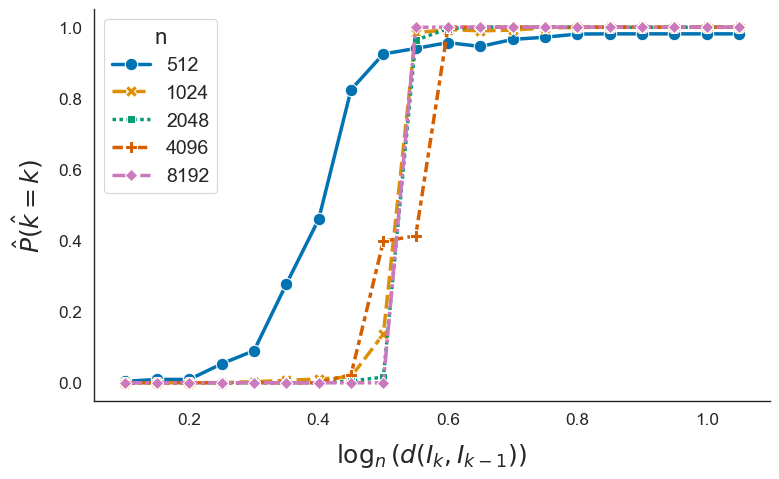

In [17]:
plt.figure(figsize=(8,5))
sns.set_theme(style="white", context="paper", font_scale=1.4)

x_col = "gap_prop"
group_col = "output_tokens"
df[group_col] = df[group_col].astype(str)

# color friendly pallete
unique_methods = df[group_col].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))


# main lineplot
sns.lineplot(
    data=df,
    x=x_col,
    y='khat_exact',
    hue=group_col,
    style=group_col,
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9
)

# labeling
# plt.ylim(0, 1.05)
plt.xlabel(r"$\log_{n}(d(I_k, I_{k-1}))$", fontsize=18, labelpad=10)
plt.ylabel(r"$\hat{P}(\hat{k} = k)$", fontsize=18, labelpad=10)
# plt.legend(title="n", title_fontsize=16, fontsize=14, loc='right', frameon=True, framealpha=0.9, bbox_to_anchor = (1.05, 0.5))
plt.legend(title="n", title_fontsize=16, fontsize=14, loc='best', frameon=True)

sns.despine()
plt.tight_layout()

plt.savefig("../figures/simulation3_gap.pdf", dpi = 300)
plt.show()

## Speed Comparison Plot

In [17]:
from itertools import product
from p_tqdm import p_map

# import the utility functions
from watermarking.detections import (
    AligatorCPPDetector, WinMaxDetector, FixedWindowDetector, 
    WaterSeekerDetector, SeedBSNOTDetectorCPP, WISERDetector, KadaneDetector
)
from watermarking.pivots import (
    null_distn_gumbel, null_distn_inverse, null_distn_pf, null_distn_redgreen
)
from utils.generic import read_json
from utils.metrics import get_summarized_results, get_iou, get_rand_index, get_modified_rand_index

In [18]:
B = 50  # number of replications
vocab_size = 10000
nlist = [100, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 5000, 7500, 10000]

def run_calculation(input):
    rows = []
    n, b = input
    pivots = np.random.standard_exponential(size = n)  # (n, )  # generate sample gumbel pivots
    random_index = int(np.random.rand() * n/2)
    pivots[random_index:(random_index + int(n/6))] += 5  # create some simulated wm segments

    # run aligator
    d = AligatorCPPDetector(vocab_size)
    _, t = d.detect(pivots, null_distn_gumbel)
    rows.append({ "index": b, "n": n, "method": "Aligator", "time": t })

    # # run fw
    # d = FixedWindowDetector(vocab_size)
    # _, t = d.detect(pivots, null_distn_gumbel)
    # rows.append({ "index": b, "n": n, "method": "FW", "time": t })

    # # run seedbs
    d = SeedBSNOTDetectorCPP(vocab_size)
    _, t = d.detect(pivots, null_distn_gumbel)
    rows.append({ "index": b, "n": n, "method": "SeedBS-NOT", "time": t })

    # run waterseeker
    d = WaterSeekerDetector(vocab_size)
    _, t = d.detect(pivots, null_distn_gumbel)
    rows.append({ "index": b, "n": n, "method": "Waterseeker", "time": t })

    # run epidemic
    d = WISERDetector(vocab_size)
    _, t = d.detect(pivots, null_distn_gumbel)
    rows.append({ "index": b, "n": n, "method": "WISER", "time": t })

    return rows

parallel_rows = p_map(
    run_calculation,
    list(product(nlist, range(B))),
    num_cpus = 8
)

output_rows = [row for rows in parallel_rows for row in rows]
timedf = pd.DataFrame(output_rows)
timedf.head()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

  0%|          | 0/600 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


,index,n,method,time
0,0,100,Aligator,0.006933
1,0,100,SeedBS-NOT,0.005064
2,0,100,Waterseeker,0.000175
3,0,100,WISER,0.000483
4,1,100,Aligator,0.005926


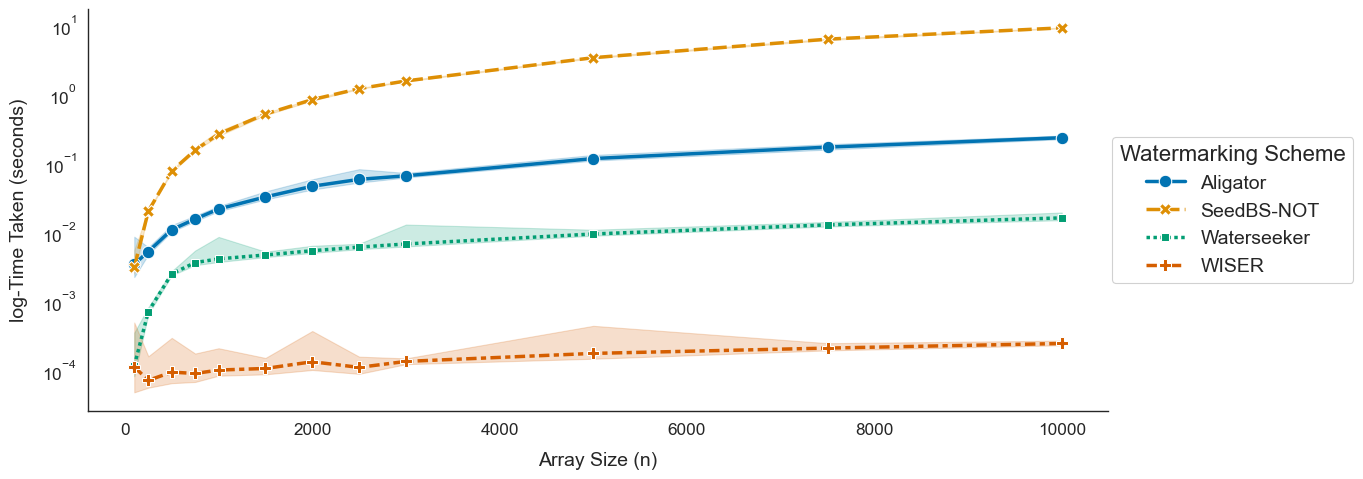

In [19]:
plt.figure(figsize=(14,5))
sns.set_theme(style="white", context="paper", font_scale=1.4)

# color friendly pallete
unique_methods = timedf['method'].unique()
palette = sns.color_palette("colorblind", n_colors=len(unique_methods))
method_colors = dict(zip(unique_methods, palette))


plot = sns.lineplot(
    data=timedf,
    x='n',
    y='time',
    hue='method',
    style='method',
    palette=method_colors,
    markers=True, 
    dashes=True,
    linewidth=2.5,
    markersize=9,
    errorbar=('pi', 99)
)

# plot.set_xscale('log')  # plot in log scale
plot.set_yscale('log')

# plot.set_title('Method Performance vs. Array Size (n)', fontsize=16, weight='bold')
plt.xlabel(f"Array Size (n)", fontsize=14, labelpad=10)
plt.ylabel("log-Time Taken (seconds)", fontsize=14, labelpad=10)

plt.legend(title='Watermarking Scheme', title_fontsize=16, fontsize=14, loc='right', frameon=True, framealpha=0.9, bbox_to_anchor = (1.25, 0.5))

# Remove top and right spines for a cleaner "academic" look
sns.despine()
plt.tight_layout()

plt.savefig("../figures/time_complexity_gumbel.pdf", dpi = 300)
plt.show()

## Experiments: Ablation Study

In [21]:
from tqdm.auto import tqdm

fname = "data_google-gemma-3-270m_n501_gumbel.json"
data = read_json(os.path.join(root_output_path, fname))
true_intervals =  [(start, end) for (start, end, interval_type) in data['configuration']['intervals'] if interval_type != 'unwatermarked']
vocab_size = data['configuration']['vocab_size']

block_sizes = [5, 10, 25, 50, 75, 125, 175, 250]

rows = []
for i, block_size in tqdm(list(product(range(len(data['data'])), block_sizes))):
    pivots = np.array(data['data'][i]['pivots'])
    pivots[np.isinf(pivots)] = pivots[~np.isinf(pivots)].max() # replace by maximum for infinite values

    # perform detection
    d = WISERDetector(vocab_size, rho = 0.25)
    est_intervals, time_taken = d.detect(pivots, null_distn_gumbel, block_size=block_size)
    ri, mri = get_modified_rand_index(est_intervals, true_intervals, pivots.shape[0])

    rows.append({
        "sample_index": i,
        "block_size": block_size,
        "IOU": get_iou(est_intervals, true_intervals),
        "RI": ri,
        "MRI": mri
    })

# convert to dataframe
blocks_df = pd.DataFrame(rows)
blocks_df.shape

  0%|          | 0/1600 [00:00<?, ?it/s]

(1600, 5)

/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_3681/2575508575.py:13: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.boxplot(data=long_df, x="block_size", y="Score", hue="Metric", palette=palette, width=0.6, fliersize=2)


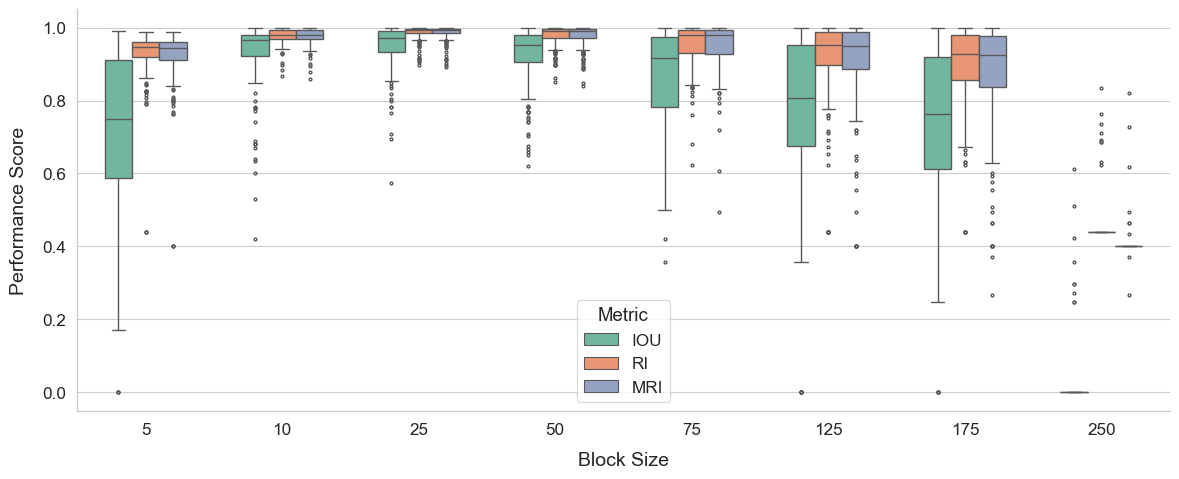

In [24]:
long_df = blocks_df.melt(
    id_vars=["sample_index", "block_size"],
    value_vars=["IOU", "RI", "MRI"],
    var_name="Metric",
    value_name="Score"
)


plt.figure(figsize=(12,5))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
palette = sns.color_palette("Set2")  # custom color palette (colorblind friendly)

ax = sns.boxplot(data=long_df, x="block_size", y="Score", hue="Metric", palette=palette, width=0.6, fliersize=2)

# ax.set_title("Ablation Study: Effect of Block Size on Detection Performance", fontsize=18, pad=20)
ax.set_xlabel("Block Size", fontsize=14, labelpad=10)
ax.set_ylabel("Performance Score", fontsize=14, labelpad=10)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # rotate x labels if needed
# handles, labels = ax.get_legend_handles_labels() # improve legend
# ax.legend(handles[:2], labels[:2], title="Metric", loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig("../figures/ablation_block_size_gumbel.pdf", dpi = 300)
plt.show()

In [25]:
rho_vals = np.arange(0.1, 1, step=0.1)

rows = []
for i, rho in tqdm(list(product(range(len(data['data'])), rho_vals))):
    pivots = np.array(data['data'][i]['pivots'])
    pivots[np.isinf(pivots)] = pivots[~np.isinf(pivots)].max() # replace by maximum for infinite values

    # perform detection
    d = WISERDetector(vocab_size, rho = round(float(rho), 3))
    est_intervals, time_taken = d.detect(pivots, null_distn_gumbel, block_size=25)  # keep block_size fixed
    ri, mri = get_modified_rand_index(est_intervals, true_intervals, pivots.shape[0])

    rows.append({
        "sample_index": i,
        "rho": rho,
        "IOU": get_iou(est_intervals, true_intervals),
        "RI": ri,
        "MRI": mri 
    })

# convert to dataframe
rho_df = pd.DataFrame(rows)
print(rho_df.shape)

  0%|          | 0/1800 [00:00<?, ?it/s]

(1800, 5)


/var/folders/v9/p596rfjn6f5cxry5bh_b_0cw0000gn/T/ipykernel_3681/763154064.py:14: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.boxplot(data=long_df, x="rho_label", y="Score", hue="Metric", palette=palette, width=0.6, fliersize=2)


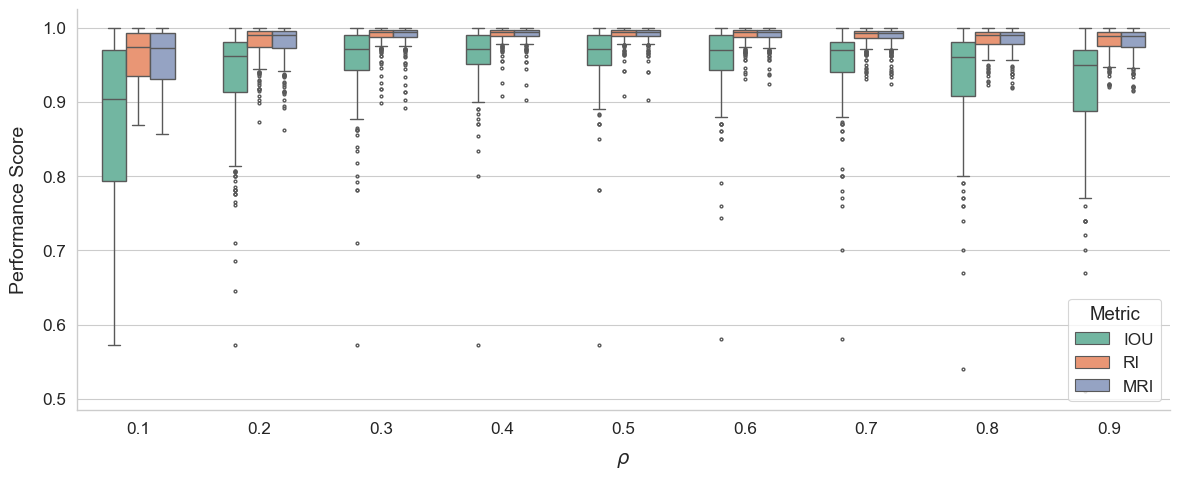

In [27]:
rho_df["rho_label"] = rho_df["rho"].map(lambda x: f"{x:.1f}")
long_df = rho_df.melt(
    id_vars=["sample_index", "rho_label"],
    value_vars=["IOU", "RI", "MRI"],
    var_name="Metric",
    value_name="Score"
)

# set style
plt.figure(figsize=(12,5))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
palette = sns.color_palette("Set2")  # custom color palette (colorblind friendly)

ax = sns.boxplot(data=long_df, x="rho_label", y="Score", hue="Metric", palette=palette, width=0.6, fliersize=2)

# ax.set_title("Ablation Study: Effect of Block Size on Detection Performance", fontsize=18, pad=20)
ax.set_xlabel(r"$\rho$", fontsize=14, labelpad=10)
ax.set_ylabel("Performance Score", fontsize=14, labelpad=10)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)  # rotate x labels if needed
# handles, labels = ax.get_legend_handles_labels() # improve legend
# ax.legend(handles[:2], labels[:2], title="Metric", loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

sns.despine()
plt.tight_layout()

plt.savefig("../figures/ablation_rho_gumbel.pdf", dpi = 300)
plt.show()

# Generating Tables

In [9]:
import os
import pandas as pd
import numpy as np

In [15]:
def format_metric(val, low=None, high=None, bold=False, digits=3):
    """Format value with optional CI."""
    if pd.isna(val):
        return ""
    
    val_str = f"{val:.{digits}f}"
    
    if low is not None and high is not None and not (pd.isna(low) or pd.isna(high)):
        ci_str = f"({low:.2f}-{high:.2f})"
        out = f"{val_str} {ci_str}"
    else:
        out = val_str

    if bold:
        out = f"\\textbf{{{out}}}"
    
    return out


def format_model_cell(model_name, vocab_size):
    """Split model name into two lines + vocab."""
    if "/" in model_name:
        org, name = model_name.split("/", 1)
    else:
        org, name = "", model_name
    
    return f"\\makecell[l]{{{org} \\\\ {name} \\\\ ({vocab_size})}}"


def generate_latex_table(df, metrics=None, digits=3, bold_best=True, watermarking_method = "gumbel"):
    """
    Generate LaTeX table string.
    """
    if metrics is None:
        metrics = {
            "IOU": "iou",
            "Precision": "precision",
            "Recall": "recall",
            "F1": "f1",
            "RI": "rand_index",
            "MRI": "modified_rand_index"
        }

    lines = []

    # Header
    header = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\resizebox{\\textwidth}{!}{\n"
        "\\begin{tabular}{ll" + "r" * len(metrics) + "}\n"
        "\\toprule\n"
        "\\textbf{Model Name} & \\textbf{Method} & "
        + " & ".join([f"\\textbf{{{k}}}" for k, v in metrics.items()])
        + " \\\\\n\\midrule"
    )
    lines.append(header)

    # Process per model
    for model_name, g in df.groupby("model_name"):
        g = g.copy()

        vocab_size = g["vocab_size"].iloc[0]

        # find best per metric (for bolding)
        best_idx = {}
        if bold_best:
            for k, v in metrics.items():
                best_idx[v] = g.iloc[1:][v].idxmax()  # ignore oracle

        model_cell = format_model_cell(model_name, vocab_size)
        first = True

        for _, row in g.iterrows():
            row_cells = []

            # model column (multirow style manually)
            if first:
                row_cells.append(
                    f"\\multirow{{{len(g)}}}{{*}}{{\n        {model_cell}\n    }}"
                )
                first = False
            else:
                row_cells.append("")

            # method column
            row_cells.append(f"\\texttt{{{row['method']}}}")

            # metric columns
            for k, v in metrics.items():
                val = row.get(v)
                low = row.get(f"{v}_lower")
                high = row.get(f"{v}_upper")

                bold = bold_best and (row.name == best_idx[v])

                cell = format_metric(val, low, high, bold, digits)
                row_cells.append(cell)

            lines.append(" & ".join(row_cells) + " \\\\")

        lines.append("\\midrule")

    # Footer
    footer = (
        "\\bottomrule\n"
        "\\end{tabular}}\n"
        f"\\caption{{Results for {watermarking_method} Watermarking}}\n"
        f"\\label{{tab:results-{watermarking_method}}}\n"
        "\\end{table}"
    )
    lines.append(footer)

    return "\n".join(lines)

In [51]:
# read the detection files
df = pd.read_csv(os.path.join("..", "data", "n1000_detections.csv"))
df

,model_name,iou,iou_median,iou_lower,iou_upper,precision,recall,f1,rand_index,rand_index_median,...,time,time_lower,time_upper,khat_over,khat_under,khat_exact,kdiff,method,vocab_size,watermark_method
0,facebook/opt-125m,0.925013,0.953719,0.576965,0.980002,0.991000,0.991,0.991000,0.992769,0.996006,...,0.001177,0.001090,0.001254,0.000,0.00,1.000,0.000000,Oracle,50272,gumbel
1,facebook/opt-125m,0.885191,0.891402,0.589883,0.980066,0.992500,0.988,0.990245,0.988635,0.993415,...,0.000154,0.000122,0.000231,0.045,0.04,0.915,0.380789,WISER,50272,gumbel
2,facebook/opt-125m,0.771151,0.751656,0.618101,0.941431,0.501667,0.903,0.645000,0.923248,0.925106,...,0.002657,0.002555,0.002920,1.000,0.00,0.000,4.000000,Kadane,50272,gumbel
3,facebook/opt-125m,0.700556,0.735519,0.322417,0.916433,0.387318,0.950,0.550284,0.973663,0.984201,...,0.020276,0.019544,0.021829,0.975,0.02,0.005,10.797916,Aligator,50272,gumbel
4,facebook/opt-125m,0.449807,0.463456,0.123083,0.697619,0.783750,0.312,0.446324,0.899621,0.917117,...,0.264398,0.255985,0.274373,0.000,1.00,0.000,3.043846,SeedBS,50272,gumbel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,meta-llama/Meta-Llama-3-8B,0.916403,0.944394,0.703020,0.986711,0.990000,0.998,0.993984,0.992485,0.995033,...,0.000151,0.000122,0.000187,0.060,0.01,0.930,0.264575,WISER,128256,pf
140,meta-llama/Meta-Llama-3-8B,0.797841,0.770714,0.573734,0.980132,0.498333,0.897,0.640714,0.923195,0.921039,...,0.003304,0.002643,0.003671,1.000,0.00,0.000,4.000000,Kadane,128256,pf
141,meta-llama/Meta-Llama-3-8B,0.776549,0.817216,0.442300,0.897371,0.695980,0.975,0.812194,0.982158,0.984568,...,0.021983,0.020304,0.023688,0.755,0.01,0.235,4.363485,Aligator,128256,pf
142,meta-llama/Meta-Llama-3-8B,0.444946,0.441026,0.154826,0.726177,0.831000,0.518,0.638188,0.942090,0.957851,...,0.257360,0.234810,0.282127,0.000,0.92,0.080,2.176006,SeedBS,128256,pf


In [52]:
df.columns

Index(['model_name', 'iou', 'iou_median', 'iou_lower', 'iou_upper',
       'precision', 'recall', 'f1', 'rand_index', 'rand_index_median',
       'rand_index_lower', 'rand_index_upper', 'modified_rand_index',
       'modified_rand_index_median', 'modified_rand_index_lower',
       'modified_rand_index_upper', 'time', 'time_lower', 'time_upper',
       'khat_over', 'khat_under', 'khat_exact', 'kdiff', 'method',
       'vocab_size', 'watermark_method'],
      dtype='object')

In [56]:
# filter for Gumbel watermarking
# watermarking_method = "gumbel"
# watermarking_method = "inverse"
# watermarking_method = "redgreen"
watermarking_method = "pf"

subdf = df.loc[df['watermark_method'] == watermarking_method]
print(generate_latex_table(subdf, watermarking_method=watermarking_method))

\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{llrrrrrr}
\toprule
\textbf{Model Name} & \textbf{Method} & \textbf{IOU} & \textbf{Precision} & \textbf{Recall} & \textbf{F1} & \textbf{RI} & \textbf{MRI} \\
\midrule
\multirow{6}{*}{
        \makecell[l]{facebook \\ opt-1.3b \\ (50272)}
    } & \texttt{Oracle} & 0.911 (0.68-0.97) & 0.995 & 0.995 & 0.995 & 0.992 (0.98-1.00) & 0.991 (0.97-1.00) \\
 & \texttt{WISER} & \textbf{0.879 (0.68-0.97)} & 0.986 & \textbf{0.995} & \textbf{0.990} & \textbf{0.989 (0.95-1.00)} & \textbf{0.988 (0.95-1.00)} \\
 & \texttt{Kadane} & 0.743 (0.53-0.93) & 0.494 & 0.890 & 0.636 & 0.906 (0.86-0.96) & 0.903 (0.85-0.96) \\
 & \texttt{Aligator} & 0.394 (0.07-0.81) & 0.235 & 0.841 & 0.367 & 0.951 (0.85-0.99) & 0.943 (0.84-0.98) \\
 & \texttt{SeedBS} & 0.408 (0.00-0.70) & 0.705 & 0.252 & 0.371 & 0.861 (0.60-0.96) & 0.847 (0.58-0.95) \\
 & \texttt{WaterSeeker} & 0.640 (0.46-0.83) & \textbf{1.000} & 0.761 & 0.864 & 0.956 (0.87-0.99) & 0.950 (0.86